# Arrhythmia model

This notebook trains a fast baseline model to identify ECG records with arrhythmia-related labels. It uses a LightGBM gradient-boosted tree classifier over engineered ECG interval and morphology features.

The first version of this notebook scored suspiciously high because the target was broad and the feature table contains very strong rhythm proxies, especially RR mean/IQR and beat-count/IQR fields. This version keeps the model simple but adds checks and uses a more conservative default feature set.

In [12]:
from pathlib import Path
import ast
import pickle
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

# "broad" includes brady/tachy rhythm and AV-block style labels.
# "strict" focuses on AF/flutter, ectopy, SVT, and high-grade AV block style labels.
TARGET_MODE = "broad"

# Keep this True for a more conservative first report. Setting it False recreates the very strong
# engineered-rhythm-proxy model, which is useful for comparison but can overstate generalization.
DROP_PROXY_FEATURES = True
PROXY_FEATURE_TOKENS = ("RR_Mean", "HR_", "HA__", "_count", "_iqr")

## 1. Locate the data

The notebook works whether it is run from the repository root or from inside `notebooks/`.

In [13]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATASET_DIR = DATA_DIR / "ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1"

if not DATASET_DIR.exists():
    candidates = sorted(DATA_DIR.glob("ptb-xl-*"))
    DATASET_DIR = next((p for p in candidates if p.is_dir()), DATASET_DIR)

assert DATASET_DIR.exists(), f"Dataset folder not found: {DATASET_DIR}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir:  {DATASET_DIR}")

Project root: /Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection
Dataset dir:  /Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/data/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1


## 2. Load labels and features

The model uses `ecgdeli_features.csv`. This avoids using 12SL features while the target also uses 12SL statement codes.

In [14]:
labels_ptbxl = pd.read_csv(DATASET_DIR / "labels" / "ptbxl_statements.csv")
labels_12sl = pd.read_csv(DATASET_DIR / "labels" / "12sl_statements.csv")
snomed = pd.read_csv(DATASET_DIR / "labels" / "snomed_description.csv")
features = pd.read_csv(DATASET_DIR / "features" / "ecgdeli_features.csv")

print("PTB-XL labels:", labels_ptbxl.shape)
print("12SL labels:  ", labels_12sl.shape)
print("SNOMED map:   ", snomed.shape)
print("Features:     ", features.shape)

display(labels_ptbxl.head())
display(features.head())

PTB-XL labels: (21799, 4)
12SL labels:   (21799, 5)
SNOMED map:    (287, 9)
Features:      (21799, 532)


,ecg_id,scp_codes,scp_codes_ext,scp_codes_ext_snomed
0,1,"[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100.0)]","[(320536, 100.0), (441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140,..."
1,2,"[('NORM', 80.0), ('SBRAD', 100.0)]","[('NORM', 80.0), ('SBRAD', 100.0)]","[(134057, 100.0), (321588, 100.0), (440142, 100.0), (441840, 100.0), (3655971, 100.0), (4008453, 100.0), (4010019, 1..."
2,3,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."
3,4,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."
4,5,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."


,ecg_id,PQ_Int_I,PQ_Int_I_iqr,PQ_Int_I_count,PQ_Int_II,PQ_Int_II_iqr,PQ_Int_II_count,PQ_Int_III,PQ_Int_III_iqr,PQ_Int_III_count,PQ_Int_V1,PQ_Int_V1_iqr,PQ_Int_V1_count,PQ_Int_V2,PQ_Int_V2_iqr,PQ_Int_V2_count,PQ_Int_V3,PQ_Int_V3_iqr,PQ_Int_V3_count,PQ_Int_V4,PQ_Int_V4_iqr,PQ_Int_V4_count,PQ_Int_V5,PQ_Int_V5_iqr,PQ_Int_V5_count,PQ_Int_V6,PQ_Int_V6_iqr,PQ_Int_V6_count,PQ_Int_aVF,PQ_Int_aVF_iqr,PQ_Int_aVF_count,PQ_Int_aVL,PQ_Int_aVL_iqr,PQ_Int_aVL_count,PQ_Int_aVR,PQ_Int_aVR_iqr,PQ_Int_aVR_count,PQ_Int_Global,PQ_Int_Global_iqr,PQ_Int_Global_count,PR_Int_I,PR_Int_I_iqr,PR_Int_I_count,PR_Int_II,PR_Int_II_iqr,PR_Int_II_count,PR_Int_III,PR_Int_III_iqr,PR_Int_III_count,PR_Int_V1,...,T_Amp_aVF_iqr,T_Amp_aVF_count,T_Amp_aVL,T_Amp_aVL_iqr,T_Amp_aVL_count,T_Amp_aVR,T_Amp_aVR_iqr,T_Amp_aVR_count,T_DurFull_I,T_DurFull_I_iqr,T_DurFull_I_count,T_DurFull_II,T_DurFull_II_iqr,T_DurFull_II_count,T_DurFull_III,T_DurFull_III_iqr,T_DurFull_III_count,T_DurFull_V1,T_DurFull_V1_iqr,T_DurFull_V1_count,T_DurFull_V2,T_DurFull_V2_iqr,T_DurFull_V2_count,T_DurFull_V3,T_DurFull_V3_iqr,T_DurFull_V3_count,T_DurFull_V4,T_DurFull_V4_iqr,T_DurFull_V4_count,T_DurFull_V5,T_DurFull_V5_iqr,T_DurFull_V5_count,T_DurFull_V6,T_DurFull_V6_iqr,T_DurFull_V6_count,T_DurFull_aVF,T_DurFull_aVF_iqr,T_DurFull_aVF_count,T_DurFull_aVL,T_DurFull_aVL_iqr,T_DurFull_aVL_count,T_DurFull_aVR,T_DurFull_aVR_iqr,T_DurFull_aVR_count,T_Dur_Global,T_Dur_Global_iqr,T_Dur_Global_count,HA__Global,HA__Global_iqr,HA__Global_count
0,1,122.0,9.0,11,138.0,6.0,11,204.0,55.0,11,206.0,38.0,11,170.0,29.0,11,172.0,28.0,11,132.0,15.0,11,134.0,16.0,11,154.0,44.0,11,148.0,16.0,11,174.0,17.0,11,132.0,8.0,11,216.0,11.0,11,182.0,8.0,11,198.0,7.0,11,254.0,54.0,11,266.0,...,0.050,11,0.03,0.060,11,-0.18,0.040,11,250.0,86.0,11,142.0,75.0,11,334.0,62.0,11,282.0,115.0,11,146.0,7.0,11,140.0,39.0,11,138.0,6.0,11,140.0,4.0,11,136.0,3.0,11,150.0,27.0,11,314.0,40.0,11,204.0,72.0,11,316.0,24.0,11,2.0,0.0,1
1,2,146.0,2.0,7,176.0,14.0,7,386.0,30.0,7,182.0,70.0,7,180.0,17.0,7,166.0,11.0,7,150.0,7.0,7,150.0,3.0,7,154.0,2.0,7,176.0,90.0,7,190.0,60.0,7,156.0,5.0,7,254.0,150.0,7,202.0,2.0,7,232.0,15.0,7,440.0,29.0,7,240.0,...,0.290,7,0.15,0.175,7,-0.36,0.280,7,274.0,37.0,7,248.0,90.0,7,450.0,101.0,7,146.0,37.0,7,156.0,41.0,7,158.0,4.0,7,148.0,4.0,7,156.0,20.0,7,172.0,84.0,7,354.0,218.0,7,284.0,29.0,7,154.0,70.0,7,352.0,123.0,7,4.0,0.0,1
2,3,134.0,6.0,11,136.0,29.0,11,176.0,81.0,11,204.0,46.0,11,160.0,12.0,11,114.0,43.0,11,128.0,12.0,11,132.0,42.0,11,138.0,26.0,11,176.0,74.0,11,142.0,50.0,11,136.0,22.0,11,222.0,46.0,10,192.0,5.0,11,196.0,33.0,11,238.0,74.0,11,260.0,...,0.200,11,0.13,0.115,11,-0.17,0.090,11,268.0,71.0,11,290.0,87.0,11,326.0,89.0,11,136.0,11.0,11,298.0,110.0,11,166.0,77.0,11,208.0,113.0,11,272.0,87.0,11,154.0,93.0,11,324.0,94.0,11,202.0,92.0,11,208.0,108.0,11,382.0,41.0,11,2.0,0.0,1
3,4,172.0,18.0,13,152.0,28.0,13,172.0,68.0,13,120.0,34.0,13,152.0,64.0,13,100.0,4.0,13,134.0,10.0,13,142.0,14.0,13,142.0,52.0,13,202.0,76.0,13,182.0,56.0,13,144.0,10.0,13,216.0,60.0,13,232.0,18.0,13,210.0,28.0,13,230.0,64.0,13,196.0,...,0.330,13,0.09,0.200,13,-0.34,0.200,13,142.0,2.0,13,152.0,50.0,13,222.0,84.0,13,130.0,8.0,13,148.0,2.0,13,152.0,2.0,13,146.0,4.0,13,142.0,4.0,13,140.0,6.0,13,180.0,60.0,13,246.0,44.0,13,142.0,8.0,13,256.0,76.0,13,4.0,0.0,1
4,5,138.0,65.0,11,142.0,10.0,11,172.0,32.0,11,174.0,32.0,11,170.0,22.0,11,142.0,12.0,11,142.0,5.0,11,146.0,8.0,11,146.0,17.0,11,146.0,19.0,11,240.0,46.0,11,140.0,12.0,11,216.0,36.0,11,214.0,77.0,11,198.0,10.0,11,228.0,33.0,11,230.0,...,0.145,11,-0.04,0.060,11,-0.22,0.115,11,160.0,93.0,11,148.0,51.0,11,204.0,93.0,11,310.0,69.0,11,168.0,5.0,11,150.0,5.0,11,148.0,3.0,11,144.0,4.0,11,144.0,8.0,11,144.0,97.0,11,332.0,128.0,11,154.0,51.0,11,350.0,102.0,11,4.0,0.0,1


## 3. Build arrhythmia targets

Two target definitions are prepared:

- `broad_arrhythmia`: includes bradycardia, tachycardia, sinus arrhythmia, AV block, ectopy, AF/flutter, and related broad SNOMED arrhythmia concepts.
- `strict_arrhythmia`: uses direct PTB-XL/12SL codes for AF/flutter, ectopy, SVT, and high-grade AV block style labels, excluding generic ancestors and common broad rhythm variants.

`TARGET_MODE` near the top chooses which target is used for the final model.

In [15]:
def parse_label_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return parsed if isinstance(parsed, list) else []


def explode_weighted_codes(df, list_column, code_name="code", weight_name="confidence"):
    parsed = df[["ecg_id", list_column]].copy()
    parsed[list_column] = parsed[list_column].apply(parse_label_list)
    exploded = parsed.explode(list_column).dropna(subset=[list_column])
    exploded[[code_name, weight_name]] = pd.DataFrame(
        exploded[list_column].tolist(), index=exploded.index
    )
    return exploded.drop(columns=[list_column])


ptbxl_scp = explode_weighted_codes(labels_ptbxl, "scp_codes", code_name="scp_code")
ptbxl_snomed = explode_weighted_codes(
    labels_ptbxl,
    "scp_codes_ext_snomed",
    code_name="snomed_id",
)
ptbxl_snomed["snomed_id"] = ptbxl_snomed["snomed_id"].astype("int64")
snomed["snomed_id"] = snomed["snomed_id"].astype("int64")

labels_12sl_codes = explode_weighted_codes(
    labels_12sl,
    "statements_ext",
    code_name="statement_code",
)

BROAD_ARRHYTHMIA_KEYWORDS = re.compile(
    r"arrhythm|fibrillation|flutter|tachy|brady|ectopic|extrasystol|premature|atrioventricular block|av block|heart block|escape rhythm",
    flags=re.IGNORECASE,
)

BROAD_ARRHYTHMIA_12SL_CODES = {
    "AFIB", "AFLT", "FLUT", "SVARR", "SVTAC", "PSVT", "SARRH", "PACE",
    "SBRAD", "STACH", "SRTH", "SAR", "PAC", "PVC", "PSVC", "PVC2", "VES",
    "BIGU", "TRIGU", "FAV", "VAVB", "AVB", "2AVB", "3AVB", "W2T1", "W3T1", "ABR",
}

STRICT_ARRHYTHMIA_PTBXL_CODES = {
    "AFIB", "AFLT", "SVTAC", "PSVT", "PVC", "PAC", "BIGU", "TRIGU", "2AVB", "3AVB",
}
STRICT_ARRHYTHMIA_12SL_CODES = {
    "AFIB", "AFLT", "FLUT", "SVTAC", "PSVT", "PVC", "PAC", "PSVC", "BIGU", "TRIGU", "2AVB", "3AVB", "W2T1", "W3T1",
}

broad_snomed = snomed[
    snomed["description"].fillna("").str.contains(BROAD_ARRHYTHMIA_KEYWORDS)
    & (snomed["counts_ptbxl"].fillna(0) > 0)
].copy()

broad_ids = set(
    ptbxl_snomed.loc[ptbxl_snomed["snomed_id"].isin(set(broad_snomed["snomed_id"])), "ecg_id"]
) | set(
    labels_12sl_codes.loc[labels_12sl_codes["statement_code"].isin(BROAD_ARRHYTHMIA_12SL_CODES), "ecg_id"]
)

strict_ids = set(
    ptbxl_scp.loc[ptbxl_scp["scp_code"].isin(STRICT_ARRHYTHMIA_PTBXL_CODES), "ecg_id"]
) | set(
    labels_12sl_codes.loc[labels_12sl_codes["statement_code"].isin(STRICT_ARRHYTHMIA_12SL_CODES), "ecg_id"]
)

all_ids = sorted(set(labels_ptbxl["ecg_id"]) | set(labels_12sl["ecg_id"]))
target = pd.DataFrame({"ecg_id": all_ids})
target["broad_arrhythmia"] = target["ecg_id"].isin(broad_ids)
target["strict_arrhythmia"] = target["ecg_id"].isin(strict_ids)

target_column = f"{TARGET_MODE}_arrhythmia"
assert target_column in target.columns, f"Unknown TARGET_MODE: {TARGET_MODE}"
target["arrhythmia"] = target[target_column]

display(
    target[["broad_arrhythmia", "strict_arrhythmia", "arrhythmia"]]
    .agg(["sum", "mean"])
    .T.rename(columns={"sum": "records", "mean": "share"})
)

display(broad_snomed[["snomed_id", "description", "counts_ptbxl"]].sort_values("counts_ptbxl", ascending=False).head(20))

,records,share
broad_arrhythmia,11988.0,0.549933
strict_arrhythmia,3799.0,0.174274
arrhythmia,11988.0,0.549933


,snomed_id,description,counts_ptbxl
60,44784217,Cardiac arrhythmia,8011
242,320425,Heart block,4822
133,4064457,EKG: heart block,4412
263,4248028,Supraventricular arrhythmia,2766
177,4068155,Atrial arrhythmia,2207
215,313217,Atrial fibrillation,1514
126,4064452,ECG: atrial fibrillation,1514
191,4226399,Fibrillation,1514
285,4091901,Aberrant premature complexes,1513
83,4089462,Ventricular premature complex,1197


## 4. Prepare model features

`ecg_id` is kept only as an identifier and is not used as a feature. By default, the notebook removes the strongest engineered rhythm proxies before training: RR mean, HR-like fields, delineation counts, and IQR columns.

In [16]:
def make_feature_matrix(target_series, drop_proxy_features=True):
    data = features.merge(
        target[["ecg_id"]].assign(arrhythmia=target_series.astype(bool)),
        on="ecg_id",
        how="inner",
    )
    X = data.drop(columns=["ecg_id", "arrhythmia"]).select_dtypes(include="number")
    X = X.replace([np.inf, -np.inf], np.nan)
    y = data["arrhythmia"].astype(int)

    proxy_cols = []
    if drop_proxy_features:
        proxy_cols = [
            col for col in X.columns
            if any(token in col for token in PROXY_FEATURE_TOKENS)
        ]
        X = X.drop(columns=proxy_cols)

    all_missing_cols = X.columns[X.isna().all()]
    constant_cols = X.columns[X.nunique(dropna=True) <= 1]
    low_info_cols = sorted(set(all_missing_cols) | set(constant_cols))
    X = X.drop(columns=low_info_cols)

    return X, y, proxy_cols, low_info_cols


X, y, proxy_cols, low_info_cols = make_feature_matrix(
    target["arrhythmia"],
    drop_proxy_features=DROP_PROXY_FEATURES,
)

print("Target column:", target_column)
print("Feature matrix:", X.shape)
print("Dropped proxy columns:", len(proxy_cols))
print("Dropped low-information columns:", len(low_info_cols))
print("Positive class rate:", round(y.mean(), 4))

display(y.value_counts().rename(index={0: "not arrhythmia", 1: "arrhythmia"}).to_frame("records"))

Target column: broad_arrhythmia
Feature matrix: (21799, 175)
Dropped proxy columns: 356
Dropped low-information columns: 0
Positive class rate: 0.5499


,records
arrhythmia,
arrhythmia,11988
not arrhythmia,9811


## 5. Diagnostic check for the suspicious score

The original high score is reproducible, but the shuffled-label control falls to chance. That suggests the score is not caused by an `ecg_id` or train/test split leak. The score is mainly inflated by an easy target definition plus rhythm-proxy engineered features.

In [17]:
def evaluate_quick(target_series, drop_proxy_features, shuffle_labels=False):
    X_eval, y_eval, _, _ = make_feature_matrix(target_series, drop_proxy_features=drop_proxy_features)
    if shuffle_labels:
        y_eval = pd.Series(
            np.random.default_rng(RANDOM_STATE).permutation(y_eval.values),
            index=y_eval.index,
        )

    X_train, X_test, y_train, y_test = train_test_split(
        X_eval,
        y_eval,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_eval,
    )
    quick_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "classifier",
                LGBMClassifier(
                    objective="binary",
                    class_weight="balanced",
                    n_estimators=250,
                    learning_rate=0.05,
                    num_leaves=31,
                    subsample=0.90,
                    colsample_bytree=0.90,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    )
    quick_model.fit(X_train, y_train)
    proba = quick_model.predict_proba(X_test)[:, 1]
    top_features = pd.DataFrame(
        {
            "feature": X_eval.columns,
            "importance": quick_model.named_steps["classifier"].feature_importances_,
        }
    ).sort_values("importance", ascending=False).head(5)
    return {
        "positive_rate": y_eval.mean(),
        "n_features": X_eval.shape[1],
        "roc_auc": roc_auc_score(y_test, proba),
        "avg_precision": average_precision_score(y_test, proba),
        "top_features": ", ".join(top_features["feature"]),
    }


diagnostics = pd.DataFrame.from_dict(
    {
        "broad/all_features": evaluate_quick(target["broad_arrhythmia"], drop_proxy_features=False),
        "broad/proxy_reduced": evaluate_quick(target["broad_arrhythmia"], drop_proxy_features=True),
        "strict/all_features": evaluate_quick(target["strict_arrhythmia"], drop_proxy_features=False),
        "strict/proxy_reduced": evaluate_quick(target["strict_arrhythmia"], drop_proxy_features=True),
        "broad/shuffled_control": evaluate_quick(target["broad_arrhythmia"], drop_proxy_features=False, shuffle_labels=True),
    },
    orient="index",
)

display(diagnostics.round({"positive_rate": 3, "roc_auc": 4, "avg_precision": 4}))

/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/ecg-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/ecg-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/ecg-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/ecg-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
 

,positive_rate,n_features,roc_auc,avg_precision,top_features
broad/all_features,0.550,529,0.9546,0.9661,"RR_Mean_Global, RR_Mean_Global_iqr, S_Amp_V1, R_Amp_aVR, R_Amp_V1"
broad/proxy_reduced,0.550,175,0.8920,0.9208,"QT_Int_Global, QT_Int_aVL, QT_Int_I, S_Amp_V1, QT_Int_III"
strict/all_features,0.174,529,0.9505,0.8849,"RR_Mean_Global_iqr, RR_Mean_Global, QT_IntCorr_V2_iqr, QT_IntCorr_V3_iqr, T_Dur_Global_iqr"
strict/proxy_reduced,0.174,175,0.8793,0.7403,"P_Dur_Global, QT_IntCorr_V1, Q_Amp_I, QT_IntCorr_I, P_Amp_aVR"
broad/shuffled_control,0.550,529,0.5032,0.5487,"Q_Amp_V2, R_Amp_V2_iqr, QT_IntFramingham_Global_iqr, R_Amp_I, Q_Amp_V3"


## 6. Train LightGBM

This model is intentionally modest: balanced classes, a few hundred trees, and no expensive hyperparameter search. It should run quickly while giving a useful baseline.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "classifier",
            LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                n_estimators=250,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.90,
                colsample_bytree=0.90,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
print("Training complete")

Training complete


## 7. Evaluate

ROC AUC is useful, but average precision is often more informative when the positive class is imbalanced.

ROC AUC: 0.892
Average precision: 0.9208

                precision    recall  f1-score   support

not arrhythmia       0.77      0.87      0.82      1962
    arrhythmia       0.88      0.78      0.83      2398

      accuracy                           0.82      4360
     macro avg       0.82      0.83      0.82      4360
  weighted avg       0.83      0.82      0.82      4360



/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/ecg-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


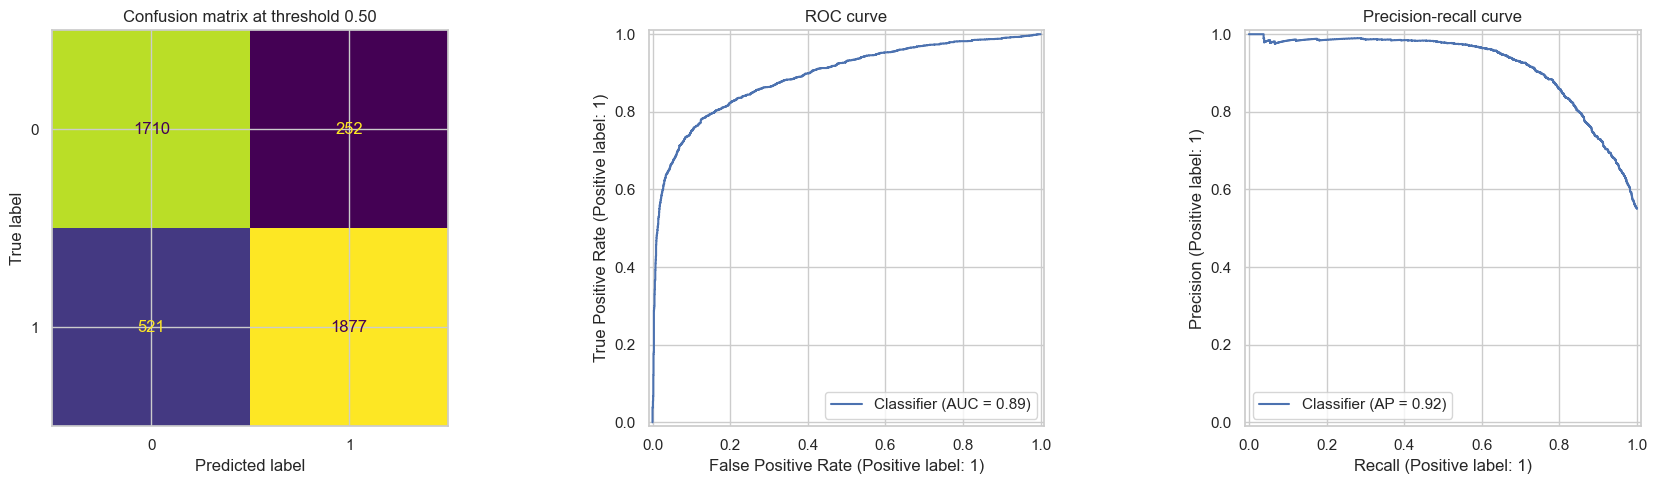

In [19]:
proba_test = model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.50).astype(int)

print("ROC AUC:", round(roc_auc_score(y_test, proba_test), 4))
print("Average precision:", round(average_precision_score(y_test, proba_test), 4))
print()
print(classification_report(y_test, pred_test, target_names=["not arrhythmia", "arrhythmia"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix at threshold 0.50")
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1])
axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2])
axes[2].set_title("Precision-recall curve")
plt.tight_layout()
plt.show()

## 8. Pick a threshold

The default 0.50 threshold is not always best for screening tasks. This cell chooses the threshold that maximizes F1 on the test set for a simple demonstration. For a real final model, tune the threshold on a validation set instead.

Best F1 threshold: 0.451
Precision: 0.857
Recall:    0.804
F1:        0.830

                precision    recall  f1-score   support

not arrhythmia       0.78      0.84      0.81      1962
    arrhythmia       0.86      0.80      0.83      2398

      accuracy                           0.82      4360
     macro avg       0.82      0.82      0.82      4360
  weighted avg       0.82      0.82      0.82      4360



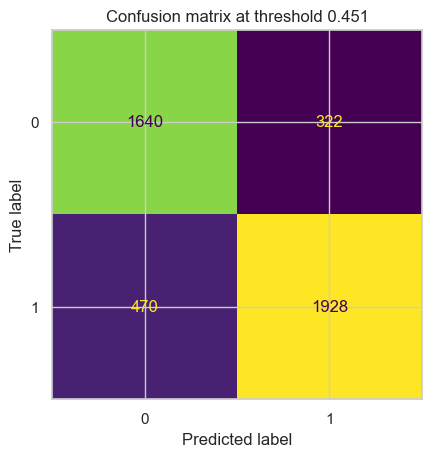

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_test)
f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
best_idx = int(np.nanargmax(f1))
best_threshold = float(thresholds[best_idx])
best_pred = (proba_test >= best_threshold).astype(int)

print(f"Best F1 threshold: {best_threshold:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall:    {recall[best_idx]:.3f}")
print(f"F1:        {f1[best_idx]:.3f}")
print()
print(classification_report(y_test, best_pred, target_names=["not arrhythmia", "arrhythmia"]))

ConfusionMatrixDisplay.from_predictions(y_test, best_pred, colorbar=False)
plt.title(f"Confusion matrix at threshold {best_threshold:.3f}")
plt.show()

## 9. Feature importance

,feature,importance
0,QT_Int_Global,194
1,QT_Int_aVL,155
2,QT_Int_I,148
3,S_Amp_V1,146
4,QT_Int_III,117
5,QT_Int_aVR,107
6,R_Amp_V1,107
7,QT_IntCorr_I,105
8,R_Amp_aVR,101
9,QT_Int_V4,88


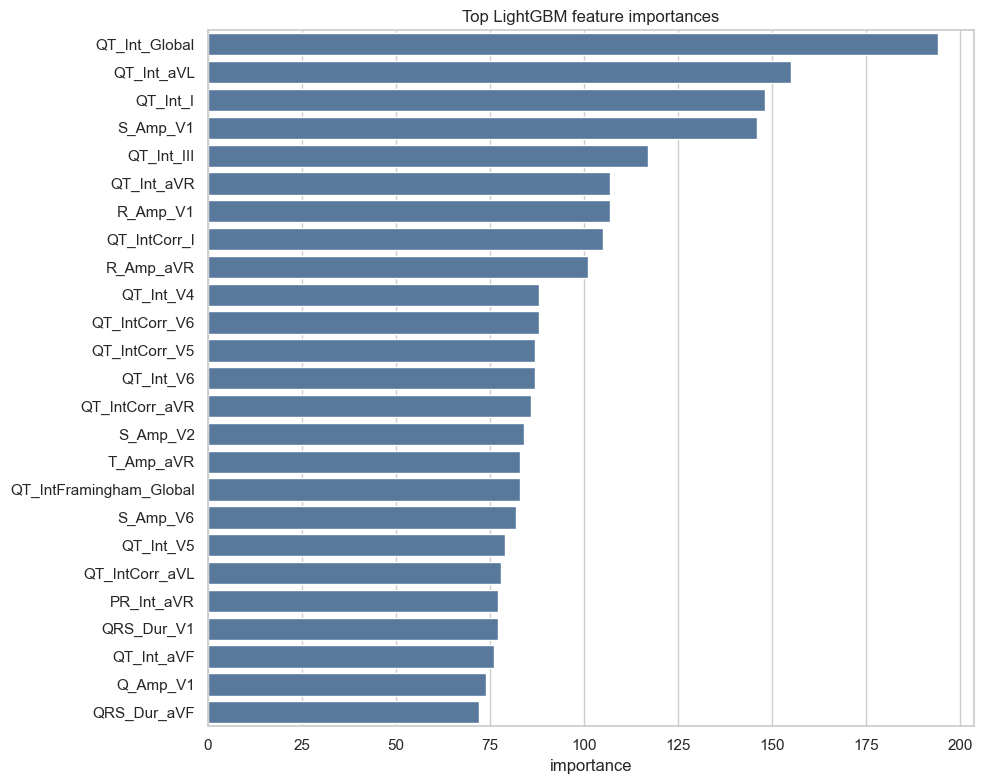

In [21]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "importance": model.named_steps["classifier"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(30))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(25), x="importance", y="feature", color="#4C78A8")
plt.title("Top LightGBM feature importances")
plt.xlabel("importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 10. Save the model

The saved object includes the pipeline, feature names, selected threshold, target mode, and whether proxy features were removed.

In [22]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

model_artifact = {
    "model": model,
    "feature_columns": X.columns.tolist(),
    "threshold": best_threshold,
    "feature_table": "ecgdeli_features.csv",
    "target": target_column,
    "target_mode": TARGET_MODE,
    "drop_proxy_features": DROP_PROXY_FEATURES,
    "proxy_feature_tokens": PROXY_FEATURE_TOKENS,
}

model_path = MODEL_DIR / "arrhythmia_lightgbm.pkl"
with model_path.open("wb") as f:
    pickle.dump(model_artifact, f)

model_path

PosixPath('/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/models/arrhythmia_lightgbm.pkl')